# All Symbols Correlation Analysis

This notebook fetches all active symbols from the Binbot API, retrieves candlestick data from Binance for each symbol, and computes a correlation matrix among all assets. The correlation matrix is visualized as a heatmap for easy analysis.

In [13]:
%pip install -q ipywidgets seaborn


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
# Import Required Libraries
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns

## Fetch All Active Symbols from API

We will use the Binbot API to get all active trading symbols.

In [ ]:
# Fetch all active symbols from the API
base_url = "https://api.terminal.binbot.in"
symbols_url = f"{base_url}/symbols"
symbols_resp = requests.get(symbols_url)
symbols_data = symbols_resp.json()["data"]
active_symbols = [s["id"] for s in symbols_data if s.get("active")]
print(f"Found {len(active_symbols)} active symbols.")
# Optionally, preview a few symbols
print("Sample symbols:", active_symbols[:10])

Found 480 active symbols.
Sample symbols: ['ETHBTC', 'QTUMBTC', 'ETCETH', 'POWRBTC', 'MANAETH', 'RLCBTC', 'ZENBTC', 'VETBTC', 'LTCUSDC', 'PHBBTC']


## Fetch Candlestick Data for Each Symbol

We will fetch recent 15m candlestick close prices for each active symbol from Binance.

In [16]:
# Fetch candlestick close prices for each symbol from Binance
from tqdm.notebook import tqdm
import time

def fetch_binance_closes(symbol, interval="15m", limit=200):
    url = "https://api.binance.com/api/v3/klines"
    params = {"symbol": symbol, "interval": interval, "limit": limit}
    resp = requests.get(url, params=params)
    if resp.status_code != 200:
        return None
    data = resp.json()
    if not data:
        return None
    df = pd.DataFrame(data, columns=[
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "qav", "num_trades", "taker_base", "taker_quote", "ignore"
    ])
    df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
    df["close"] = df["close"].astype(float)
    return df[["timestamp", "close"]]

closes_dict = {}
for symbol in tqdm(active_symbols, desc="Fetching candlesticks"):
    try:
        df = fetch_binance_closes(symbol)
        if df is not None and len(df) > 0:
            closes_dict[symbol] = df.set_index("timestamp")["close"]
        time.sleep(0.1)  # Be nice to the API
    except Exception as e:
        print(f"Failed for {symbol}: {e}")

print(f"Fetched data for {len(closes_dict)} symbols.")

Fetching candlesticks:   0%|          | 0/480 [00:00<?, ?it/s]

Fetched data for 480 symbols.


## Combine Closing Prices into a Single DataFrame

We will align all symbols' close prices by timestamp and combine them into a single DataFrame.

In [17]:
# Combine all close price series into a single DataFrame
if closes_dict:
    df_closes = pd.DataFrame(closes_dict)
    print(f"Combined DataFrame shape: {df_closes.shape}")
    display(df_closes.tail())
else:
    print("No close price data available.")

Combined DataFrame shape: (200, 480)


,ETHBTC,QTUMBTC,ETCETH,POWRBTC,MANAETH,RLCBTC,ZENBTC,VETBTC,LTCUSDC,PHBBTC,...,LDOUSDC,1000SATSUSDC,SLFUSDC,PNUTBTC,EIGENUSDC,SANDUSDC,ORCAUSDC,PHAUSDC,TRUMPUSDC,CAKEUSDC
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-09-01 22:30:00,0.03944,0.000024,0.00473,0.000001,0.000066,0.000011,0.000063,2.200000e-07,106.72,0.000005,...,1.1396,0.000033,0.0515,0.000002,1.115,0.2641,2.128,0.0995,8.25,2.360
2025-09-01 22:45:00,0.03951,0.000023,0.00473,0.000001,0.000066,0.000011,0.000063,2.200000e-07,107.44,0.000005,...,1.1484,0.000033,0.0515,0.000002,1.123,0.2656,2.142,0.1005,8.29,2.369
2025-09-01 23:00:00,0.03959,0.000023,0.00473,0.000001,0.000066,0.000011,0.000063,2.200000e-07,107.94,0.000005,...,1.1518,0.000034,0.0517,0.000002,1.133,0.2669,2.150,0.1010,8.31,2.377
2025-09-01 23:15:00,0.03951,0.000024,0.00473,0.000001,0.000066,0.000011,0.000063,2.200000e-07,108.04,0.000005,...,1.1493,0.000034,0.0513,0.000002,1.130,0.2670,2.149,0.1010,8.30,2.377
2025-09-01 23:30:00,0.03942,0.000024,0.00473,0.000001,0.000066,0.000011,0.000063,2.100000e-07,107.87,0.000005,...,1.1490,0.000034,0.0513,0.000002,1.130,0.2669,2.149,0.1007,8.32,2.379


## Compute Correlation Matrix

We will calculate the correlation matrix for the closing prices of all symbols.

In [18]:
# Compute the correlation matrix for the closing prices
if 'df_closes' in locals() and not df_closes.empty:
    corr_matrix = df_closes.corr()
    print(f"Correlation matrix shape: {corr_matrix.shape}")
    display(corr_matrix)
else:
    print("No closing price data to compute correlation matrix.")

Correlation matrix shape: (480, 480)


,ETHBTC,QTUMBTC,ETCETH,POWRBTC,MANAETH,RLCBTC,ZENBTC,VETBTC,LTCUSDC,PHBBTC,...,LDOUSDC,1000SATSUSDC,SLFUSDC,PNUTBTC,EIGENUSDC,SANDUSDC,ORCAUSDC,PHAUSDC,TRUMPUSDC,CAKEUSDC
ETHBTC,1.000000,0.515412,-0.373716,0.816425,-0.280792,0.496031,0.810711,0.532782,0.590703,0.783142,...,0.717665,0.742814,0.696639,0.796251,0.795680,0.819185,0.665932,0.828486,0.324264,0.801888
QTUMBTC,0.515412,1.000000,0.362596,0.838920,0.083033,0.126087,0.792186,0.517791,0.603086,0.819738,...,0.683952,0.837112,0.757570,0.843687,0.768250,0.652771,0.793648,0.770927,-0.200074,0.772931
ETCETH,-0.373716,0.362596,1.000000,0.149252,0.570032,-0.066291,0.128473,-0.033087,0.365788,0.179353,...,0.240704,0.251889,-0.032129,0.179341,0.176583,0.059924,0.332535,0.096218,-0.213592,0.178366
POWRBTC,0.816425,0.838920,0.149252,1.000000,0.051621,0.435692,0.955561,0.583204,0.805854,0.963037,...,0.908623,0.943663,0.781746,0.965324,0.950613,0.902954,0.927373,0.952843,0.066970,0.931804
MANAETH,-0.280792,0.083033,0.570032,0.051621,1.000000,0.052586,0.039944,-0.201663,0.364677,0.085847,...,0.215374,0.099668,-0.163136,0.013763,0.080458,0.191649,0.219806,-0.014639,-0.372689,0.005593
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SANDUSDC,0.819185,0.652771,0.059924,0.902954,0.191649,0.534129,0.905219,0.543226,0.856201,0.912594,...,0.925486,0.902973,0.698415,0.897038,0.946621,1.000000,0.903178,0.923568,0.178369,0.900959
ORCAUSDC,0.665932,0.793648,0.332535,0.927373,0.219806,0.428606,0.941753,0.558122,0.902774,0.951979,...,0.964645,0.962281,0.692785,0.939477,0.963847,0.903178,1.000000,0.943639,0.029602,0.917960
PHAUSDC,0.828486,0.770927,0.096218,0.952843,-0.014639,0.475906,0.965807,0.618623,0.813409,0.957437,...,0.930698,0.956052,0.795305,0.962797,0.973423,0.923568,0.943639,1.000000,0.186355,0.942645
TRUMPUSDC,0.324264,-0.200074,-0.213592,0.066970,-0.372689,0.231051,0.065879,-0.011423,0.120654,0.086165,...,0.081399,0.131797,0.197448,0.143489,0.187812,0.178369,0.029602,0.186355,1.000000,0.284148


## Visualize Correlation Matrix

We will plot a heatmap of the correlation matrix for visual analysis.

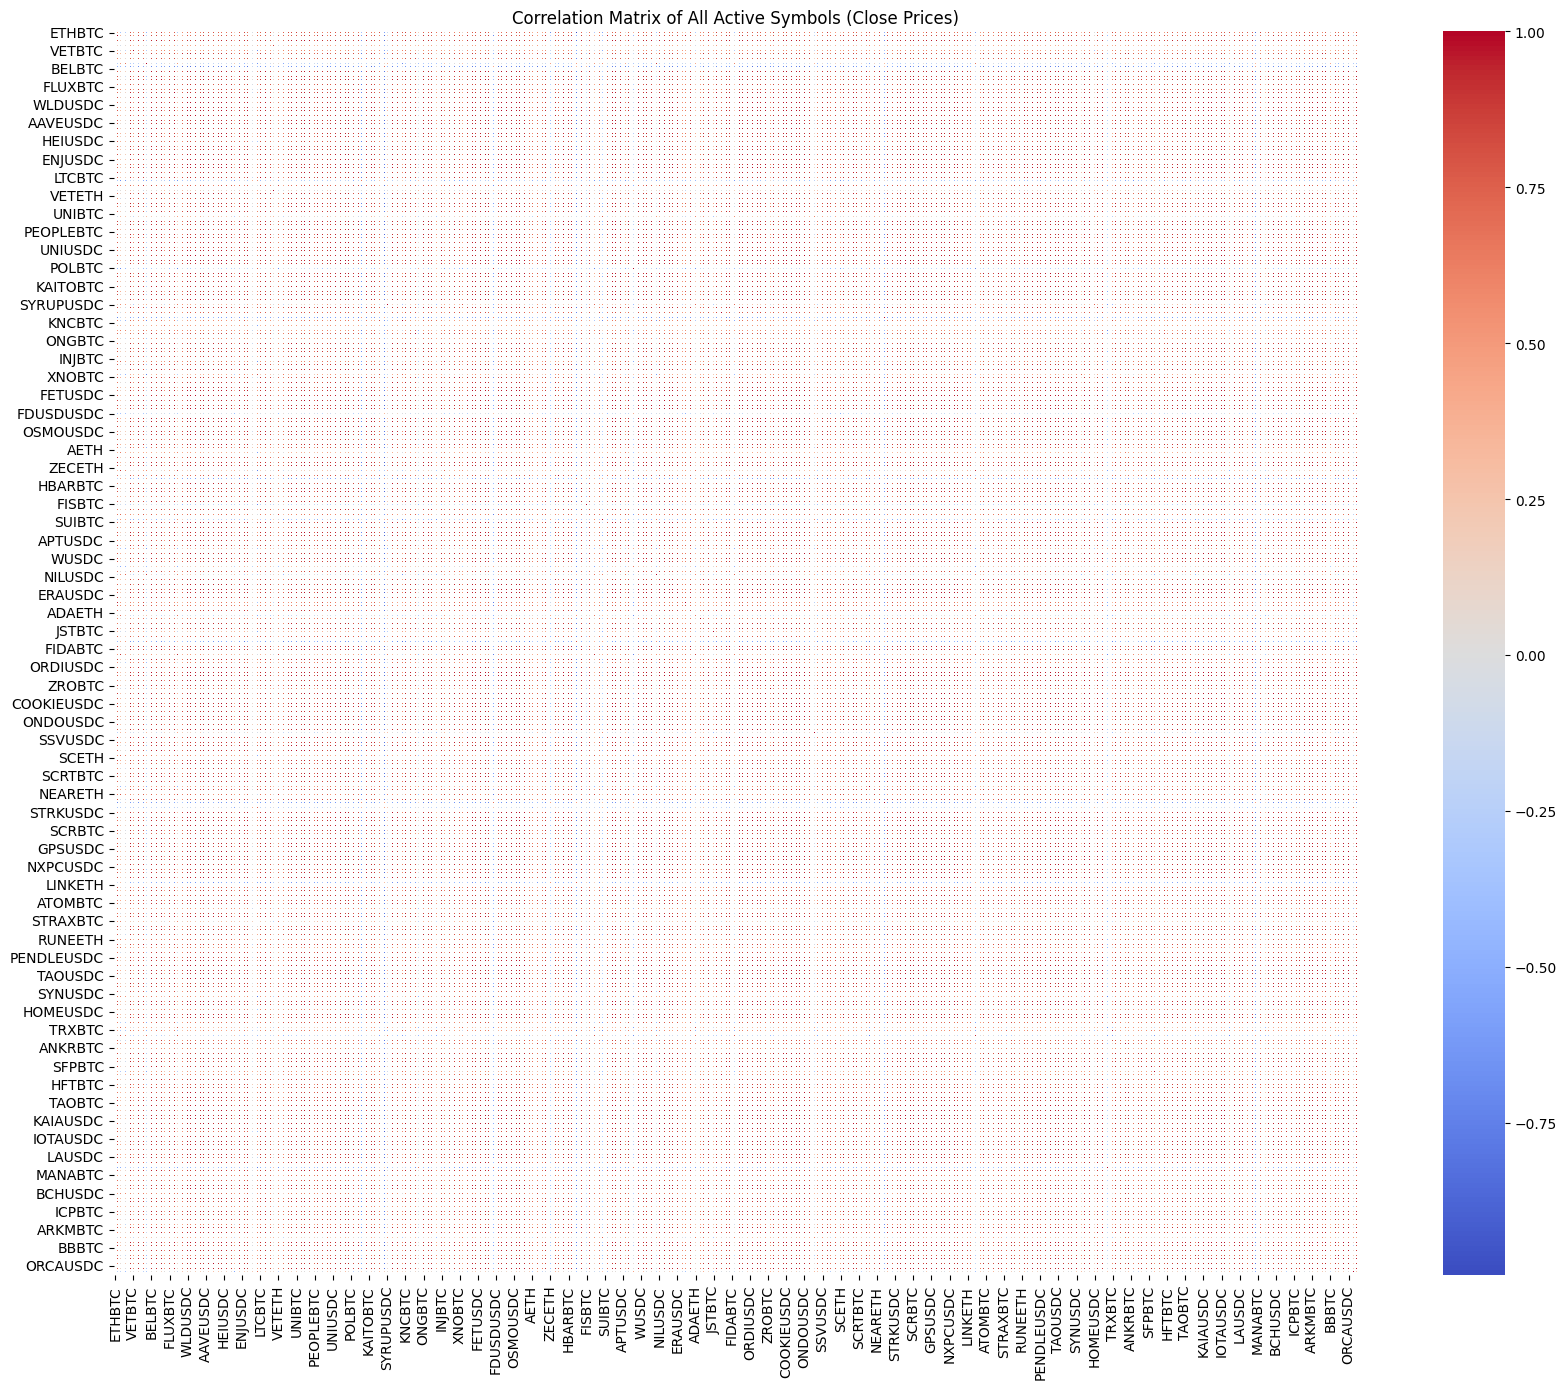

In [19]:
# Plot a heatmap of the correlation matrix
if 'corr_matrix' in locals() and not corr_matrix.empty:
    plt.figure(figsize=(18, 14))
    sns.heatmap(corr_matrix, cmap='coolwarm', center=0, square=True, linewidths=0.1)
    plt.title('Correlation Matrix of All Active Symbols (Close Prices)')
    plt.tight_layout()
    plt.show()
else:
    print("No correlation matrix to plot.")

## Group Assets by Correlation Sign and Visualize

Instead of a heatmap, we will group asset pairs by positive and negative correlations and visualize them in a scatterplot. Each point will represent a pair of assets, with the x-axis as one asset, y-axis as the other, and color indicating positive or negative correlation.

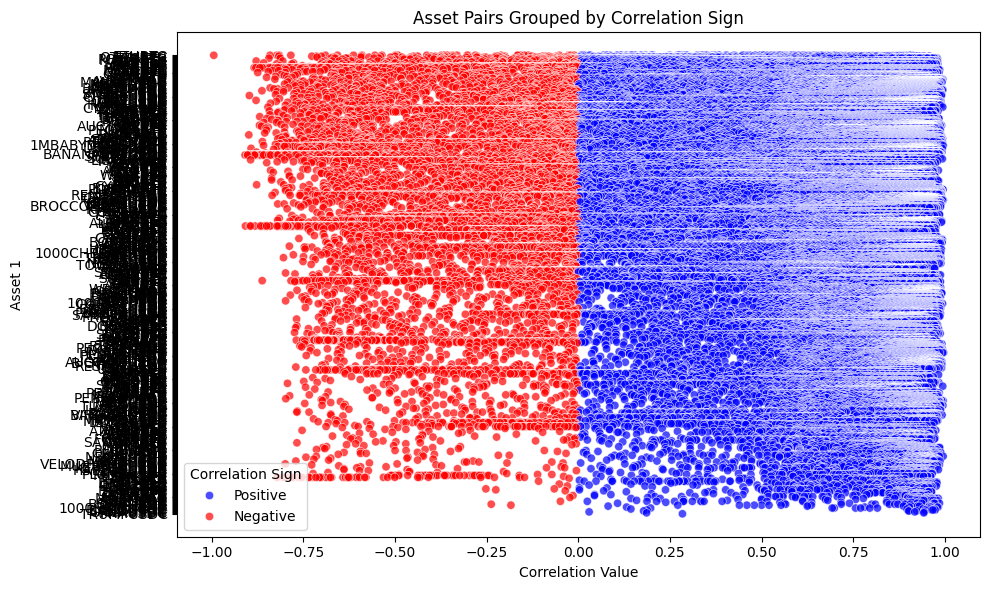

In [20]:
# Group asset pairs by correlation sign and plot as scatterplot
if 'corr_matrix' in locals() and not corr_matrix.empty:
    corr_pairs = corr_matrix.stack().reset_index()
    corr_pairs.columns = ['Asset1', 'Asset2', 'Correlation']
    # Remove self-correlations
    corr_pairs = corr_pairs[corr_pairs['Asset1'] != corr_pairs['Asset2']]
    # Drop duplicate pairs (A,B) and (B,A)
    corr_pairs['pair'] = corr_pairs.apply(lambda x: tuple(sorted([x['Asset1'], x['Asset2']])), axis=1)
    corr_pairs = corr_pairs.drop_duplicates('pair')
    # Group by sign
    corr_pairs['Sign'] = np.where(corr_pairs['Correlation'] < 0, 'Negative', 'Positive')
    # Scatterplot: x=Correlation, y=Asset1, color=Sign
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=corr_pairs,
        x='Correlation',
        y='Asset1',
        hue='Sign',
        palette={'Positive': 'blue', 'Negative': 'red'},
        alpha=0.7
    )
    plt.title('Asset Pairs Grouped by Correlation Sign')
    plt.xlabel('Correlation Value')
    plt.ylabel('Asset 1')
    plt.legend(title='Correlation Sign')
    plt.tight_layout()
    plt.show()
else:
    print("No correlation matrix to plot.")

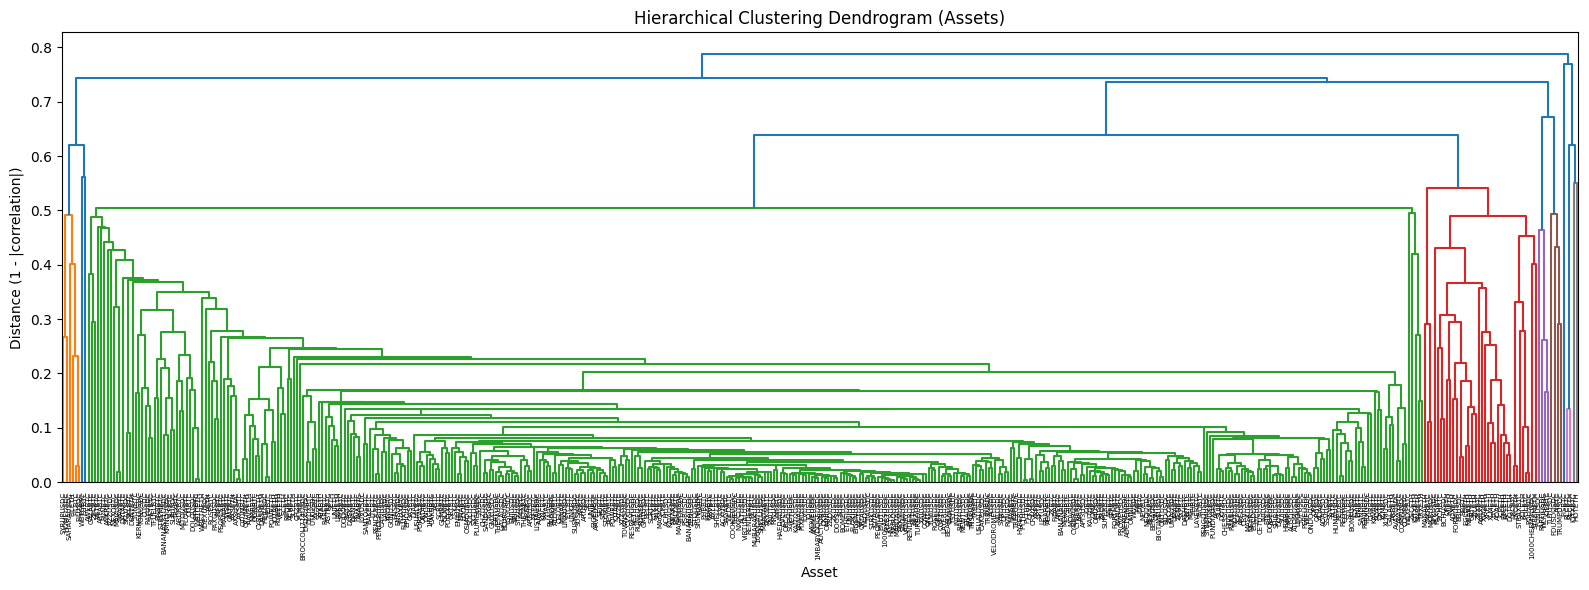

Cluster assignments (asset: cluster):
{'ETHBTC': np.int32(2), 'QTUMBTC': np.int32(2), 'ETCETH': np.int32(2), 'POWRBTC': np.int32(2), 'MANAETH': np.int32(2), 'RLCBTC': np.int32(4), 'ZENBTC': np.int32(2), 'VETBTC': np.int32(2), 'LTCUSDC': np.int32(2), 'PHBBTC': np.int32(2), 'CHZBTC': np.int32(2), 'OGNBTC': np.int32(2), 'MKRBTC': np.int32(2), 'PAXGBTC': np.int32(2), 'BELBTC': np.int32(2), 'NEARBTC': np.int32(2), 'GLMBTC': np.int32(2), 'CAKEBTC': np.int32(2), 'ARBTC': np.int32(2), 'GALABTC': np.int32(2), 'SSVETH': np.int32(2), 'FLUXBTC': np.int32(2), 'UNIETH': np.int32(2), 'LDOBTC': np.int32(2), 'APTETH': np.int32(2), 'WLDBTC': np.int32(2), 'AVAXUSDC': np.int32(2), 'MANTAUSDC': np.int32(2), 'WLDUSDC': np.int32(2), 'NEARUSDC': np.int32(2), 'JTOUSDC': np.int32(2), 'RUNEUSDC': np.int32(2), 'TRBUSDC': np.int32(2), 'NOTUSDC': np.int32(2), 'BANANABTC': np.int32(2), 'AAVEUSDC': np.int32(2), 'PNUTUSDC': np.int32(2), 'MEMEUSDC': np.int32(2), 'CHZUSDC': np.int32(2), 'HIVEUSDC': np.int32(2), 'STEEMUS

In [21]:
# Hierarchical clustering of assets based on correlation
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

if 'corr_matrix' in locals() and not corr_matrix.empty:
    # Fill NaN in correlation matrix with 0 (treat as no correlation)
    corr_filled = corr_matrix.fillna(0)
    # Convert correlation to distance
    distance_matrix = 1 - corr_filled.abs()
    # Set diagonal to 0 (distance to self)
    np.fill_diagonal(distance_matrix.values, 0)
    # Check if the matrix is square and non-empty
    if not distance_matrix.empty and distance_matrix.shape[0] == distance_matrix.shape[1]:
        # Convert to condensed distance matrix for linkage
        condensed_dist = squareform(distance_matrix.values, checks=False)
        # Perform hierarchical clustering
        Z = linkage(condensed_dist, method='average')
        # Plot dendrogram
        plt.figure(figsize=(16, 6))
        dendrogram(Z, labels=distance_matrix.columns, leaf_rotation=90)
        plt.title('Hierarchical Clustering Dendrogram (Assets)')
        plt.xlabel('Asset')
        plt.ylabel('Distance (1 - |correlation|)')
        plt.tight_layout()
        plt.show()
        # Optionally, assign cluster labels (e.g., 5 clusters)
        cluster_labels = fcluster(Z, t=5, criterion='maxclust')
        asset_clusters = dict(zip(distance_matrix.columns, cluster_labels))
        print('Cluster assignments (asset: cluster):')
        print(asset_clusters)
    else:
        print('No sufficient data for clustering (distance matrix is empty or not square).')
else:
    print('No correlation matrix to cluster.')

In [22]:
# Assign clusters using a distance threshold of 0.4 and print the results
from scipy.cluster.hierarchy import fcluster
from collections import defaultdict

if 'Z' in locals():
    cluster_labels_04 = fcluster(Z, t=0.30, criterion='distance')
    asset_clusters_04 = dict(zip(distance_matrix.columns, cluster_labels_04))
    unique_clusters_04 = set(cluster_labels_04)
    print(f"Number of clusters at distance threshold 0.4: {len(unique_clusters_04)}")
    print(f"Cluster labels: {sorted(unique_clusters_04)}")
    # Optionally, show a few assets per cluster
    clusters_dict = defaultdict(list)
    for symbol, label in asset_clusters_04.items():
        clusters_dict[label].append(symbol)
    for label, symbols in clusters_dict.items():
        print(f"Cluster {label}: {symbols[:5]}{'...' if len(symbols) > 5 else ''}")
else:
    print('No linkage matrix Z found. Run the clustering cell first.')

Number of clusters at distance threshold 0.4: 44
Cluster labels: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31), np.int32(32), np.int32(33), np.int32(34), np.int32(35), np.int32(36), np.int32(37), np.int32(38), np.int32(39), np.int32(40), np.int32(41), np.int32(42), np.int32(43), np.int32(44)]
Cluster 12: ['ETHBTC', 'TFUELBTC', 'BANANAS31USDC', 'BNBBTC', 'KMNOUSDC']...
Cluster 13: ['QTUMBTC', 'POWRBTC', 'ZENBTC', 'LTCUSDC', 'PHBBTC']...
Cluster 29: ['ETCETH', 'APTETH', 'XRPETH', 'DOTETH', 'ADAETH']...
Cluster 26: ['MANAETH', 'MKRBTC', 'MKRUSDC']
Cluster 41: ['RLCBTC', 'RLCETH']
Cluster 22: ['VETBTC']
Cluster 27: ['

In [23]:
# KMeans clustering on PCA-reduced correlation data
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import numpy as np
from collections import defaultdict, Counter

# Use the absolute correlation matrix as features
if 'corr_matrix' in locals() and not corr_matrix.empty:
    corr_features = corr_matrix.abs().fillna(0)
    # Optionally, reduce dimensionality for clustering
    pca = PCA(n_components=min(10, corr_features.shape[1]))
    features_pca = pca.fit_transform(corr_features)
    # Choose number of clusters (e.g., 5, or use elbow method)
    n_clusters = 5
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(features_pca)
    asset_kmeans_clusters = dict(zip(corr_features.index, kmeans_labels))
    clusters_dict = defaultdict(list)
    for symbol, label in asset_kmeans_clusters.items():
        clusters_dict[label].append(symbol)
    print(f'Number of clusters: {len(clusters_dict)}')
    # Collect a Counter for each cluster, counting each asset_index name only once per symbol
    cluster_counters = {}
    symbols_resp = requests.get(f"{base_url}/symbols?symbol={symbol}")
    symbols_data = symbols_resp.json()["data"]
    for label, symbols in sorted(clusters_dict.items()):
        asset_index_counter = Counter()
        for symbol in symbols:
            try:
                unique_names = set()
                for asset in symbols_data:
                    if asset["id"] == symbol:
                        for indx in asset.get("asset_indices", []):
                            asset_index_counter[indx["name"]] += 1
                        continue
                            
                
            except Exception as e:
                print(f'Error fetching for symbol {symbol}: {e}')
            cluster_counters[label] = asset_index_counter

    for key, value in cluster_counters.items():
        print(f'Cluster {key}: {value}')

else:
    print('No correlation matrix available for KMeans clustering.')

Number of clusters: 5


NameError: name 'base_url' is not defined

In [ ]:
# Assign asset index to each symbol in each cluster via PUT request
import requests

cluster_0_index = "meme"
cluster_1_index = "launchpool"
cluster_2_index = "infrastructure"
cluster_3_index = "hodler"
cluster_4_index = "layers"

# Define the mapping from cluster number to cluster index variable
cluster_indices = {
    0: cluster_0_index,
    1: cluster_1_index,
    2: cluster_2_index,
    3: cluster_3_index,
    4: cluster_4_index,
}

for cluster_num, symbols in clusters_dict.items():
    cluster_index = cluster_indices[cluster_num]
    for symbol in symbols:
        payload = {
            "id": symbol,
            "asset_indices": [
                {"id": cluster_index, "name": cluster_index.capitalize()}
            ],
        }
        
        try:
            response = requests.put(
                f"{base_url}/symbol/asset-index", json=payload
            )
            print(
                f"PUT {symbol} to cluster {cluster_num} ({cluster_index}): {response.status_code}"
            )
        except Exception as e:
            print(f"Error for symbol {symbol}: {e}")


PUT ETHBTC to cluster 3 (hodler): 200
PUT VETBTC to cluster 3 (hodler): 200
PUT GALABTC to cluster 3 (hodler): 200
PUT TUTUSDC to cluster 3 (hodler): 200
PUT WLFIUSDC to cluster 3 (hodler): 200
PUT TFUELBTC to cluster 3 (hodler): 200
PUT BANANAS31USDC to cluster 3 (hodler): 200
PUT AXSUSDC to cluster 3 (hodler): 200
PUT BNBBTC to cluster 3 (hodler): 200
PUT ZECBTC to cluster 3 (hodler): 200
PUT RVNBTC to cluster 3 (hodler): 200
PUT WBTCBTC to cluster 3 (hodler): 200
PUT KMNOUSDC to cluster 3 (hodler): 200
PUT IOTXETH to cluster 3 (hodler): 200
PUT WBTCETH to cluster 3 (hodler): 200
PUT DATABTC to cluster 3 (hodler): 200
PUT AXSBTC to cluster 3 (hodler): 200
PUT OGBTC to cluster 3 (hodler): 200
PUT WBETHETH to cluster 3 (hodler): 200
PUT TONUSDC to cluster 3 (hodler): 200
PUT CUSDC to cluster 3 (hodler): 200
PUT FLOWBTC to cluster 3 (hodler): 200
PUT BNBETH to cluster 3 (hodler): 200
PUT DENTETH to cluster 3 (hodler): 200
PUT RIFBTC to cluster 3 (hodler): 200
PUT AWEBTC to cluster 3 (ho